<a href="https://www.kaggle.com/code/aamir28/sonar-return-classification-system?scriptVersionId=330427318" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#001012;border-radius:14px;font-family:'Courier New',monospace;overflow:hidden;border:1px solid #00585e;">

  <div style="background:linear-gradient(90deg,#001a1e,#003338,#001a1e);padding:18px 36px;border-bottom:1px solid #00585e;display:flex;justify-content:space-between;align-items:center;">
    <div style="display:flex;align-items:center;gap:14px;">
      <span style="font-size:1.8rem;">📡</span>
      <div>
        <div style="font-size:1.05rem;font-weight:900;color:#5eebd6;letter-spacing:1px;">SONAR RETURN CLASSIFICATION SYSTEM</div>
        <div style="font-size:0.65rem;color:#0e8a8f;letter-spacing:3px;margin-top:2px;">UCI SONAR DATASET · ROCK vs MINE DISCRIMINATION</div>
      </div>
    </div>
    <div style="text-align:right;font-size:0.65rem;color:#0e8a8f;letter-spacing:1px;">CONTACT LOG<br>MUHAMMAD AAMIR</div>
  </div>

  <!-- Console readout grid -->
  <div style="display:grid;grid-template-columns:repeat(5,1fr);background:#000a0c;border-bottom:1px solid #00585e;">
    <div style="padding:14px 16px;border-right:1px solid #00585e;">
      <div style="font-size:0.58rem;color:#0e8a8f;letter-spacing:2px;margin-bottom:5px;">CONTACTS LOGGED</div>
      <div style="font-size:1.4rem;font-weight:800;color:#5eebd6;">208</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #00585e;">
      <div style="font-size:0.58rem;color:#0e8a8f;letter-spacing:2px;margin-bottom:5px;">FREQUENCY BANDS</div>
      <div style="font-size:1.4rem;font-weight:800;color:#5eebd6;">60</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #00585e;">
      <div style="font-size:0.58rem;color:#0e8a8f;letter-spacing:2px;margin-bottom:5px;">MINE CONTACTS</div>
      <div style="font-size:1.4rem;font-weight:800;color:#ff5d5d;">111 (53.4%)</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #00585e;">
      <div style="font-size:0.58rem;color:#0e8a8f;letter-spacing:2px;margin-bottom:5px;">ROCK CONTACTS</div>
      <div style="font-size:1.4rem;font-weight:800;color:#5eebd6;">97 (46.6%)</div>
    </div>
    <div style="padding:14px 16px;">
      <div style="font-size:0.58rem;color:#0e8a8f;letter-spacing:2px;margin-bottom:5px;">TOP BAND</div>
      <div style="font-size:1.4rem;font-weight:800;color:#ffd54f;">Freq_11</div>
    </div>
  </div>

  <div style="padding:22px 36px;display:grid;grid-template-columns:1fr 1fr;gap:20px;">
    <div>
      <div style="font-size:0.62rem;letter-spacing:3px;color:#0e8a8f;margin-bottom:10px;">▌ MISSION BRIEF</div>
      <p style="color:#5a9094;font-size:0.82rem;line-height:1.8;margin:0;">Each of 208 sonar contacts is described by 60 energy readings spanning a swept frequency range, capturing the spectral signature of the echo bounced off either a rock formation or a metal cylinder (mine). The task: build a classifier that tells the two apart from spectral shape alone — no human eye on the waveform required.</p>
    </div>
    <div>
      <div style="font-size:0.62rem;letter-spacing:3px;color:#0e8a8f;margin-bottom:10px;">▌ EARLY SCAN RESULTS</div>
      <div style="display:flex;flex-direction:column;gap:7px;">
        <div style="background:#000a0c;border-left:3px solid #5eebd6;padding:7px 12px;font-size:0.78rem;color:#5a9094;">Mid-band frequencies (9-13, 45-49) carry the strongest rock/mine signal</div>
        <div style="background:#000a0c;border-left:3px solid #ffd54f;padding:7px 12px;font-size:0.78rem;color:#5a9094;">Mine returns show higher mean energy at low-to-mid bands</div>
        <div style="background:#000a0c;border-left:3px solid #ff5d5d;padding:7px 12px;font-size:0.78rem;color:#5a9094;">Spectral peak position differs: mines peak ~band 25-28, rocks more spread</div>
      </div>
    </div>
  </div>

  <div style="background:#000a0c;padding:8px 36px;border-top:1px solid #00585e;">
    <span style="font-size:0.65rem;color:#00585e;">█ ROCK &nbsp;&nbsp; █ MINE &nbsp;&nbsp;|&nbsp;&nbsp; Author: Muhammad Aamir · Kaggle Notebook</span>
  </div>
</div>


## 📡 Table of Contents
1. [Setup & Data Loading](#1)
2. [EDA & Class Balance](#2)
3. [Feature Engineering](#3)
4. [Average Spectral Signatures — Rock vs Mine](#4)
5. [Individual Waveforms — What Does a Contact Look Like?](#5)
6. [Most Discriminative Frequency Bands](#6)
7. [Dimensionality Reduction — PCA Projection](#7)
8. [Correlation Structure Among Frequency Bands](#8)
9. [ML Classifiers — Rock vs Mine](#9)
10. [Key Takeaways](#10)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

# Sonar-console dark theme — deep teal/black with cyan readout glow
BG, PANEL, GRID = '#001012','#000a0c','#00585e'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':GRID,
    'axes.labelcolor':'#5a9094','axes.titlecolor':'#5eebd6','axes.titlesize':13,
    'xtick.color':'#0e8a8f','ytick.color':'#0e8a8f','text.color':'#5a9094',
    'grid.color':'#001a1e','grid.linewidth':0.6,
    'legend.facecolor':BG,'legend.edgecolor':GRID,'font.family':'DejaVu Sans',
})

ROCK  = '#5eebd6'
MINE  = '#ff5d5d'
GOLD  = '#ffd54f'
PURPLE= '#b794f6'
LABEL_PAL = {'R': ROCK, 'M': MINE}
CMAP_SONAR = LinearSegmentedColormap.from_list('sn', [BG, ROCK, '#d4fff5'])
CMAP_DIV = LinearSegmentedColormap.from_list('dv', [MINE, BG, ROCK])
print('✅  Sonar console theme online. 208 contacts loaded.')


✅  Sonar console theme online. 208 contacts loaded.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/mikhail1681/connectionist-bench-mines-and-rocks/Sonar.csv')
print(f'Shape: {df.shape}')
df.head(5)

Shape: (208, 61)


,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,Freq_7,Freq_8,Freq_9,Freq_10,...,Freq_52,Freq_53,Freq_54,Freq_55,Freq_56,Freq_57,Freq_58,Freq_59,Freq_60,Label
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## 2. EDA & Class Balance <a id='2'></a>


In [3]:
print('=== Nulls ===')
print(df.isnull().sum().sum(), 'total missing values')
print(f'\n=== Class Balance ===')
print(df["Label"].value_counts())
print(f'Mine prevalence: {(df["Label"]=="M").mean()*100:.1f}%')
print('\n=== Descriptive Statistics (first 5 bands) ===')
df.iloc[:,:5].describe().round(3)


=== Nulls ===
0 total missing values

=== Class Balance ===
Label
M    111
R     97
Name: count, dtype: int64
Mine prevalence: 53.4%

=== Descriptive Statistics (first 5 bands) ===


,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5
count,208.000,208.000,208.000,208.000,208.000
mean,0.029,0.038,0.044,0.054,0.075
std,0.023,0.033,0.038,0.047,0.056
min,0.002,0.001,0.002,0.006,0.007
25%,0.013,0.016,0.019,0.024,0.038
50%,0.023,0.031,0.034,0.044,0.062
75%,0.036,0.048,0.058,0.064,0.100
max,0.137,0.234,0.306,0.426,0.401


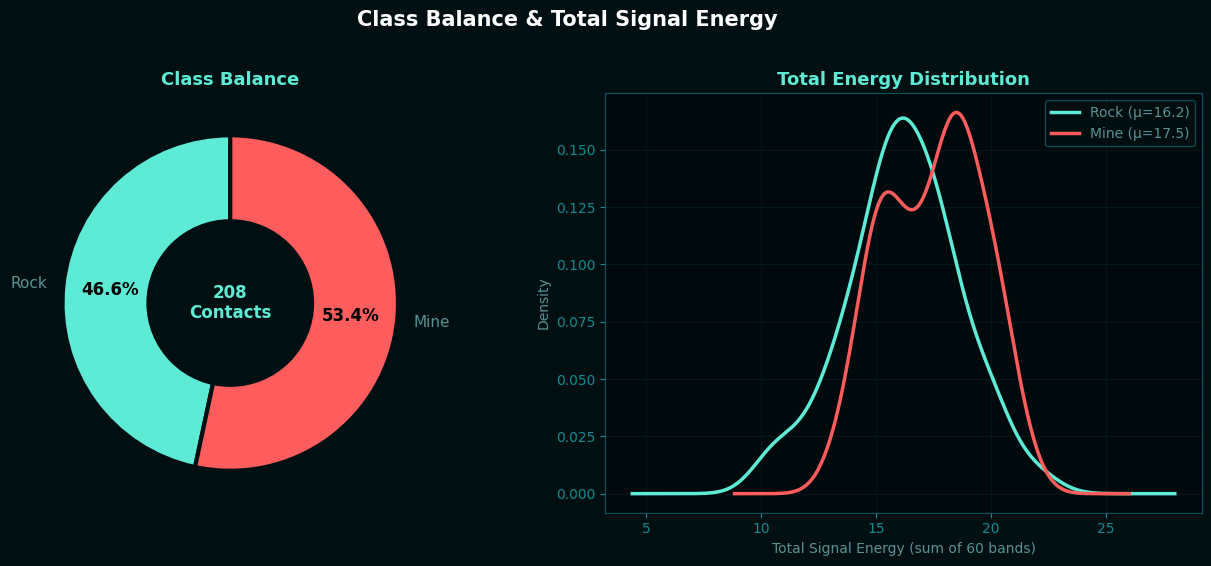

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Class Balance & Total Signal Energy', fontsize=15, fontweight='bold', color='white', y=1.02)

# 1. Class balance donut
ax = axes[0]
counts = df['Label'].value_counts()
wedges, texts, ats = ax.pie([counts['R'], counts['M']], labels=['Rock','Mine'],
    colors=[ROCK, MINE], autopct='%1.1f%%', startangle=90, pctdistance=0.72,
    wedgeprops=dict(linewidth=3, edgecolor=BG), textprops=dict(fontsize=11, color='#5a9094'))
for at in ats: at.set_color('black'); at.set_fontsize(12); at.set_fontweight('bold')
centre = plt.Circle((0,0), 0.5, fc=BG); ax.add_patch(centre)
ax.text(0, 0, f'{len(df)}\nContacts', ha='center', va='center', fontsize=12, fontweight='bold', color='#5eebd6')
ax.set_title('Class Balance', fontweight='bold')

# 2. Total energy by label
ax = axes[1]
freq_cols = [c for c in df.columns if c.startswith('Freq_')]
df['total_energy'] = df[freq_cols].sum(axis=1)
for lbl, color in LABEL_PAL.items():
    data = df[df['Label']==lbl]['total_energy']
    data.plot.kde(ax=ax, color=color, lw=2.5, label=f'{"Mine" if lbl=="M" else "Rock"} (μ={data.mean():.1f})')
ax.set_xlabel('Total Signal Energy (sum of 60 bands)'); ax.set_ylabel('Density')
ax.set_title('Total Energy Distribution', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('01_balance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 3. Feature Engineering <a id='3'></a>


In [5]:
# Spectral summary statistics per contact
df['peak_band'] = df[freq_cols].idxmax(axis=1).str.replace('Freq_','').astype(int)
df['peak_energy'] = df[freq_cols].max(axis=1)
df['mean_energy'] = df[freq_cols].mean(axis=1)
df['energy_std'] = df[freq_cols].std(axis=1)

# Low/mid/high band energy aggregates (spectral shape descriptors)
low_bands  = [f'Freq_{i}' for i in range(1,21)]
mid_bands  = [f'Freq_{i}' for i in range(21,41)]
high_bands = [f'Freq_{i}' for i in range(41,61)]
df['low_energy']  = df[low_bands].mean(axis=1)
df['mid_energy']  = df[mid_bands].mean(axis=1)
df['high_energy'] = df[high_bands].mean(axis=1)

df['label_enc'] = (df['Label']=='M').astype(int)

print('Engineered: peak_band, peak_energy, mean_energy, energy_std, low/mid/high_energy, label_enc')
print(df[['peak_band','mean_energy','low_energy','mid_energy','high_energy']].describe().round(3))


Engineered: peak_band, peak_energy, mean_energy, energy_std, low/mid/high_energy, label_enc
       peak_band  mean_energy  low_energy  mid_energy  high_energy
count    208.000      208.000     208.000     208.000      208.000
mean      25.904        0.281       0.234       0.521        0.089
std        5.134        0.039       0.094       0.088        0.046
min       15.000        0.172       0.066       0.210        0.019
25%       22.000        0.254       0.161       0.476        0.059
50%       26.000        0.281       0.226       0.523        0.078
75%       28.000        0.309       0.291       0.575        0.106
max       42.000        0.368       0.480       0.776        0.268


## 4. Average Spectral Signatures — Rock vs Mine <a id='4'></a>


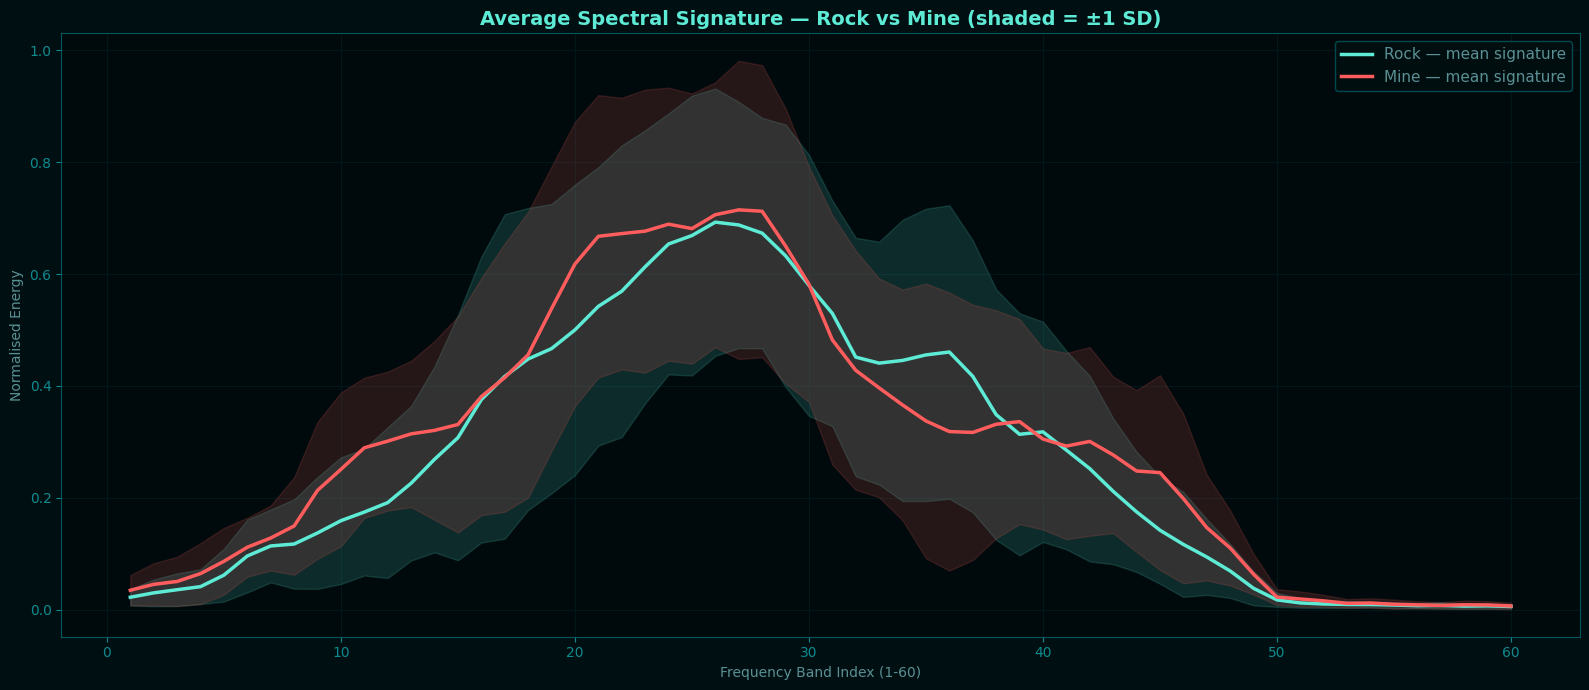

Rock mean peak around band ~27 | Mine mean peak around band ~25


In [6]:
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)

band_idx = np.arange(1, 61)
rock_mean = df[df['Label']=='R'][freq_cols].mean().values
mine_mean = df[df['Label']=='M'][freq_cols].mean().values
rock_std  = df[df['Label']=='R'][freq_cols].std().values
mine_std  = df[df['Label']=='M'][freq_cols].std().values

ax.fill_between(band_idx, rock_mean-rock_std, rock_mean+rock_std, color=ROCK, alpha=0.15, zorder=2)
ax.fill_between(band_idx, mine_mean-mine_std, mine_mean+mine_std, color=MINE, alpha=0.15, zorder=2)
ax.plot(band_idx, rock_mean, color=ROCK, lw=2.5, label='Rock — mean signature', zorder=4)
ax.plot(band_idx, mine_mean, color=MINE, lw=2.5, label='Mine — mean signature', zorder=4)

ax.set_xlabel('Frequency Band Index (1-60)'); ax.set_ylabel('Normalised Energy')
ax.set_title('Average Spectral Signature — Rock vs Mine (shaded = ±1 SD)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('02_signatures.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Rock mean peak around band ~27 | Mine mean peak around band ~25')


## 5. Individual Waveforms — What Does a Contact Look Like? <a id='5'></a>


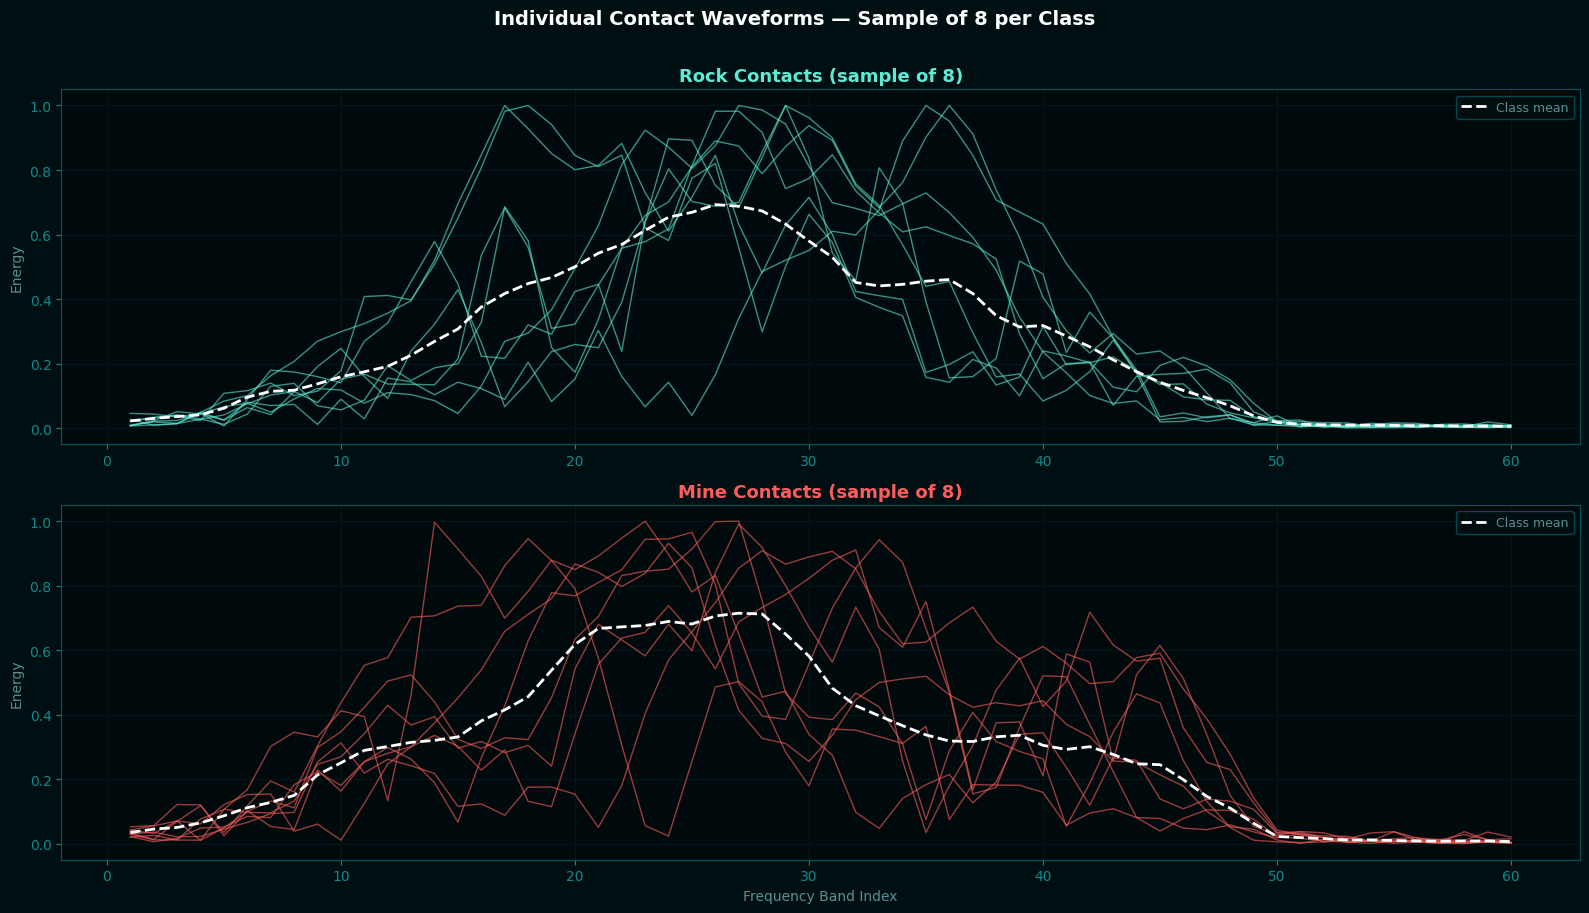

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.patch.set_facecolor(BG)
fig.suptitle('Individual Contact Waveforms — Sample of 8 per Class', fontsize=14, fontweight='bold', color='white', y=1.01)

rock_sample = df[df['Label']=='R'].sample(8, random_state=42)
mine_sample = df[df['Label']=='M'].sample(8, random_state=42)

ax = axes[0]
for _, row in rock_sample.iterrows():
    ax.plot(band_idx, row[freq_cols].values, color=ROCK, lw=1, alpha=0.6, zorder=3)
ax.plot(band_idx, rock_mean, color='white', lw=2, ls='--', zorder=5, label='Class mean')
ax.set_ylabel('Energy'); ax.set_title('Rock Contacts (sample of 8)', fontweight='bold', color=ROCK)
ax.legend(fontsize=9); ax.grid(True, zorder=0)

ax2 = axes[1]
for _, row in mine_sample.iterrows():
    ax2.plot(band_idx, row[freq_cols].values, color=MINE, lw=1, alpha=0.6, zorder=3)
ax2.plot(band_idx, mine_mean, color='white', lw=2, ls='--', zorder=5, label='Class mean')
ax2.set_xlabel('Frequency Band Index'); ax2.set_ylabel('Energy')
ax2.set_title('Mine Contacts (sample of 8)', fontweight='bold', color=MINE)
ax2.legend(fontsize=9); ax2.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('03_waveforms.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. Most Discriminative Frequency Bands <a id='6'></a>


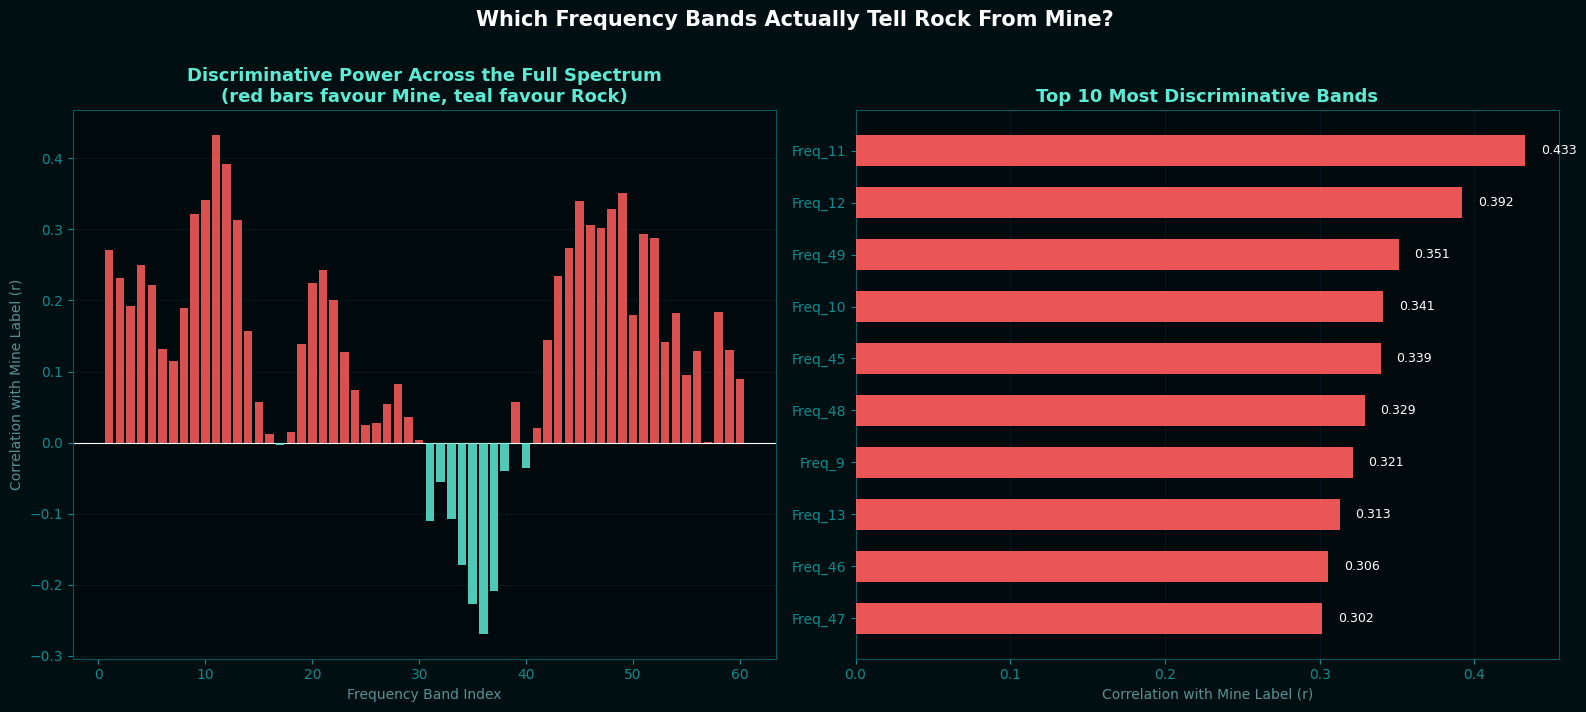

In [8]:
band_corrs = pd.Series({i: stats.pearsonr(df[f'Freq_{i}'], df['label_enc'])[0] for i in range(1,61)})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Which Frequency Bands Actually Tell Rock From Mine?', fontsize=15, fontweight='bold', color='white', y=1.01)

# 1. Correlation by band index (full spectrum view)
ax = axes[0]
colors_bar = [MINE if c>0 else ROCK for c in band_corrs.values]
ax.bar(band_corrs.index, band_corrs.values, color=colors_bar, width=0.8, zorder=3, alpha=0.85)
ax.axhline(0, color='white', lw=0.8)
ax.set_xlabel('Frequency Band Index'); ax.set_ylabel('Correlation with Mine Label (r)')
ax.set_title('Discriminative Power Across the Full Spectrum\n(red bars favour Mine, teal favour Rock)', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Top 10 ranked bar
ax = axes[1]
top10 = band_corrs.abs().sort_values(ascending=False).head(10)
top10_signed = band_corrs[top10.index]
colors_top = [MINE if v>0 else ROCK for v in top10_signed.values]
ax.barh(range(10), top10_signed.values[::-1], color=colors_top[::-1], height=0.6, zorder=3, alpha=0.92)
ax.set_yticks(range(10)); ax.set_yticklabels([f'Freq_{i}' for i in top10.index[::-1]], fontsize=10)
ax.set_xlabel('Correlation with Mine Label (r)')
ax.set_title('Top 10 Most Discriminative Bands', fontweight='bold')
for i, v in enumerate(top10_signed.values[::-1]):
    ax.text(v+(0.01 if v>0 else -0.01), i, f'{v:.3f}', va='center', ha='left' if v>0 else 'right', fontsize=9, color='white')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('04_discriminative.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. Dimensionality Reduction — PCA Projection <a id='7'></a>


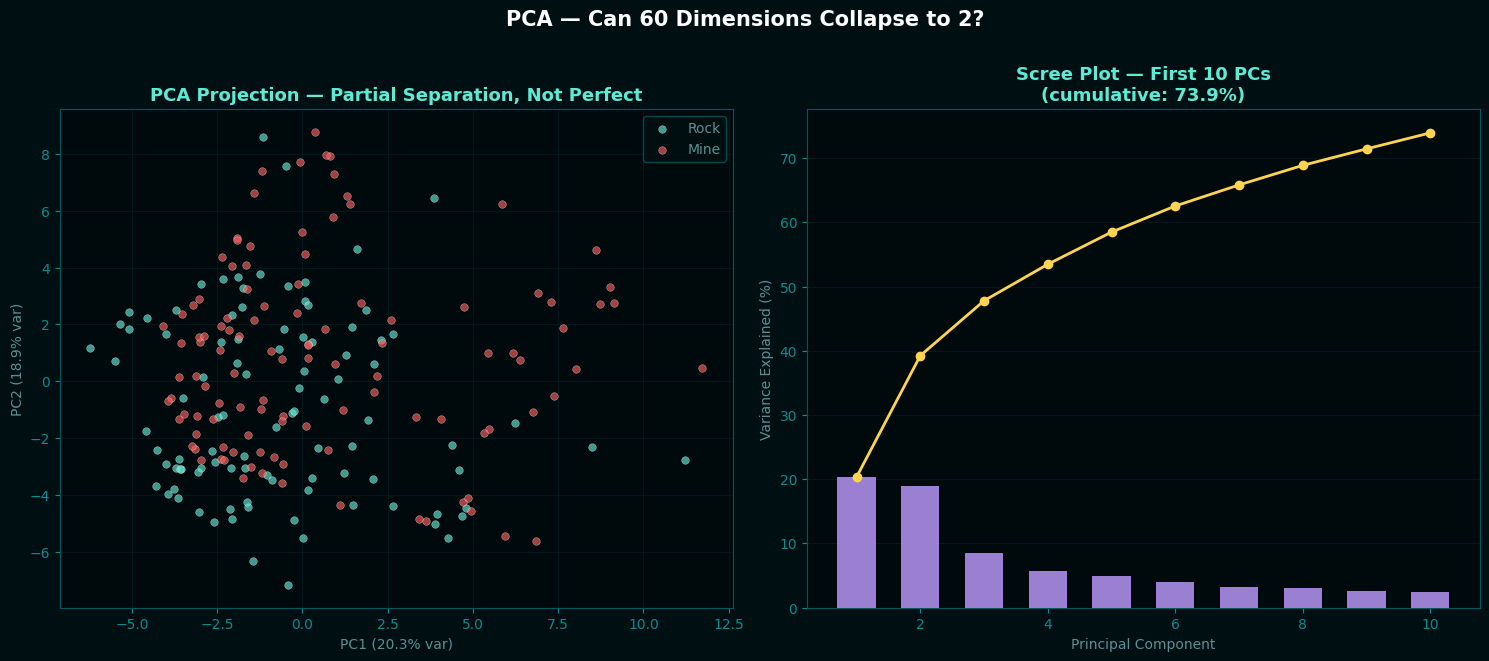

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df[freq_cols])
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('PCA — Can 60 Dimensions Collapse to 2?', fontsize=15, fontweight='bold', color='white', y=1.01)

# 1. PC1 vs PC2 scatter
ax = axes[0]
for lbl, color in LABEL_PAL.items():
    mask = (df['Label']==lbl).values
    ax.scatter(X_pca[mask,0], X_pca[mask,1], color=color, s=30, alpha=0.65,
               label='Mine' if lbl=='M' else 'Rock', edgecolors='white', linewidths=0.3, zorder=4)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA Projection — Partial Separation, Not Perfect', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Explained variance (scree plot)
ax = axes[1]
cum_var = np.cumsum(pca.explained_variance_ratio_)*100
ax.bar(range(1,11), pca.explained_variance_ratio_*100, color=PURPLE, width=0.6, zorder=3, alpha=0.85)
ax.plot(range(1,11), cum_var, 'o-', color=GOLD, lw=2, ms=6, zorder=5)
ax.set_xlabel('Principal Component'); ax.set_ylabel('Variance Explained (%)')
ax.set_title(f'Scree Plot — First 10 PCs\n(cumulative: {cum_var[-1]:.1f}%)', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('05_pca.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. Correlation Structure Among Frequency Bands <a id='8'></a>


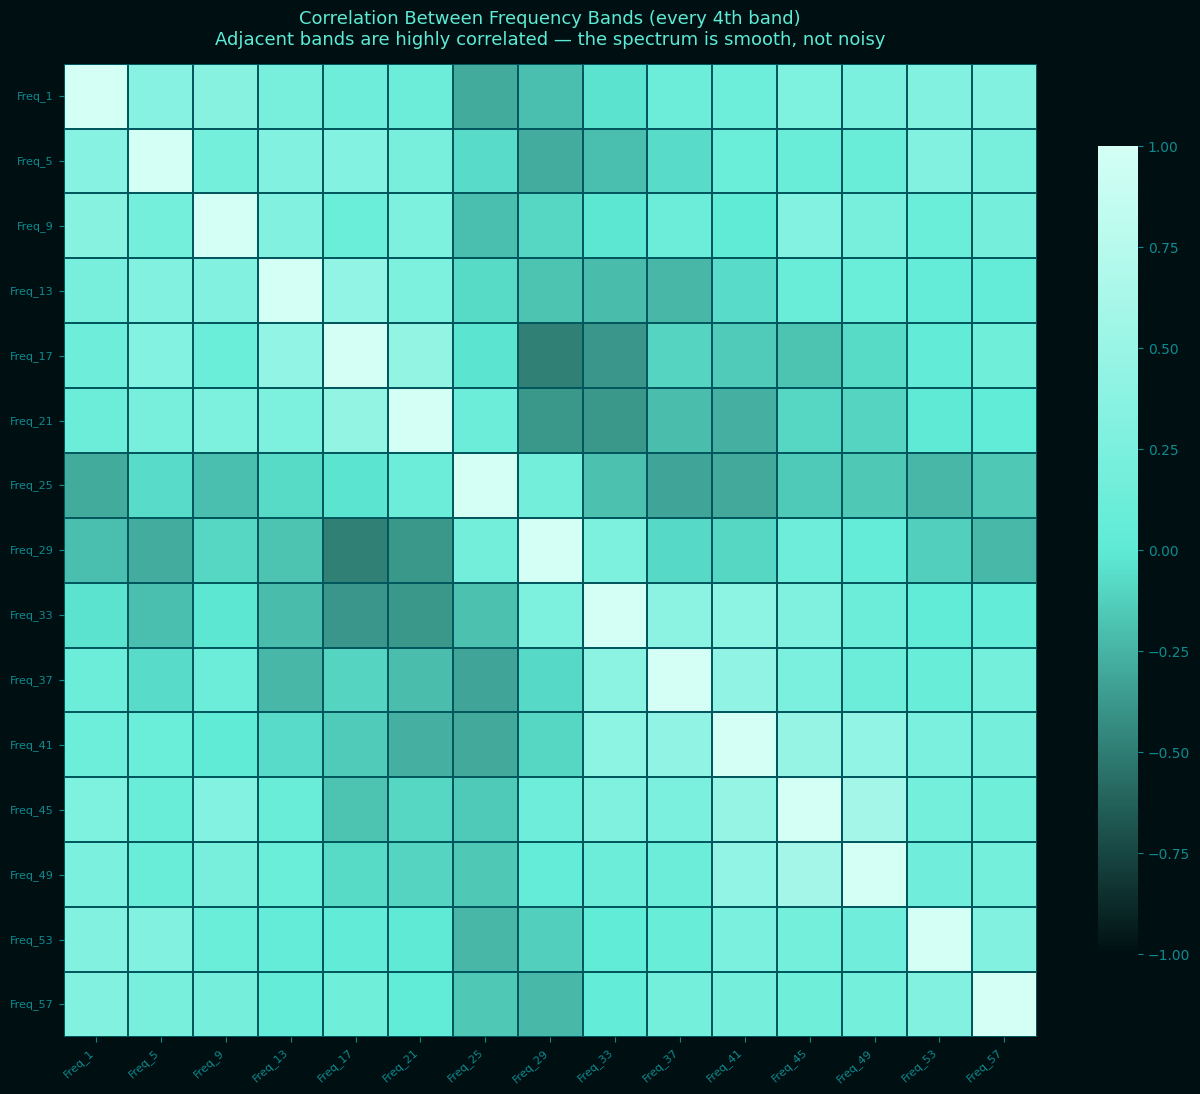

In [10]:
# Full 60x60 would be unreadable — show every 4th band for legibility
sample_bands = [f'Freq_{i}' for i in range(1,61,4)]
corr = df[sample_bands].corr()

fig, ax = plt.subplots(figsize=(13, 11))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, cmap=CMAP_SONAR, vmin=-1, vmax=1, annot=False,
            linewidths=0.2, linecolor=GRID, cbar_kws={'shrink':0.8}, ax=ax, square=True)
ax.set_title('Correlation Between Frequency Bands (every 4th band)\nAdjacent bands are highly correlated — the spectrum is smooth, not noisy',
             fontsize=13, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=42, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('06_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. ML Classifiers — Rock vs Mine <a id='9'></a>


In [11]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

X = df[freq_cols]
y = df['label_enc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_ts_s = scaler.transform(X_test)

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), True),
    'SVM (RBF kernel)':    (SVC(kernel='rbf', probability=True, random_state=42), True),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, random_state=42), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=150, random_state=42), False),
}

results = {}
for name, (model, scaled) in models.items():
    Xtr = X_tr_s if scaled else X_train
    Xts = X_ts_s if scaled else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xts)
    proba = model.predict_proba(Xts)[:,1]
    auc = roc_auc_score(y_test, proba)
    cv_scores = cross_val_score(model, Xtr, y_train, cv=5)
    results[name] = {'model':model,'preds':preds,'proba':proba,'auc':auc,'scaled':scaled,'cv_mean':cv_scores.mean()}
    print(f'=== {name} ===')
    print(classification_report(y_test, preds, target_names=['Rock','Mine']))
    print(f'ROC-AUC: {auc:.4f}  |  5-fold CV accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})\n')


=== Logistic Regression ===
              precision    recall  f1-score   support

        Rock       0.79      0.79      0.79        24
        Mine       0.82      0.82      0.82        28

    accuracy                           0.81        52
   macro avg       0.81      0.81      0.81        52
weighted avg       0.81      0.81      0.81        52

ROC-AUC: 0.8646  |  5-fold CV accuracy: 0.7760 (±0.0660)

=== SVM (RBF kernel) ===
              precision    recall  f1-score   support

        Rock       0.85      0.71      0.77        24
        Mine       0.78      0.89      0.83        28

    accuracy                           0.81        52
   macro avg       0.82      0.80      0.80        52
weighted avg       0.81      0.81      0.81        52

ROC-AUC: 0.9449  |  5-fold CV accuracy: 0.8081 (±0.0324)

=== Random Forest ===
              precision    recall  f1-score   support

        Rock       0.89      0.71      0.79        24
        Mine       0.79      0.93      0.85   

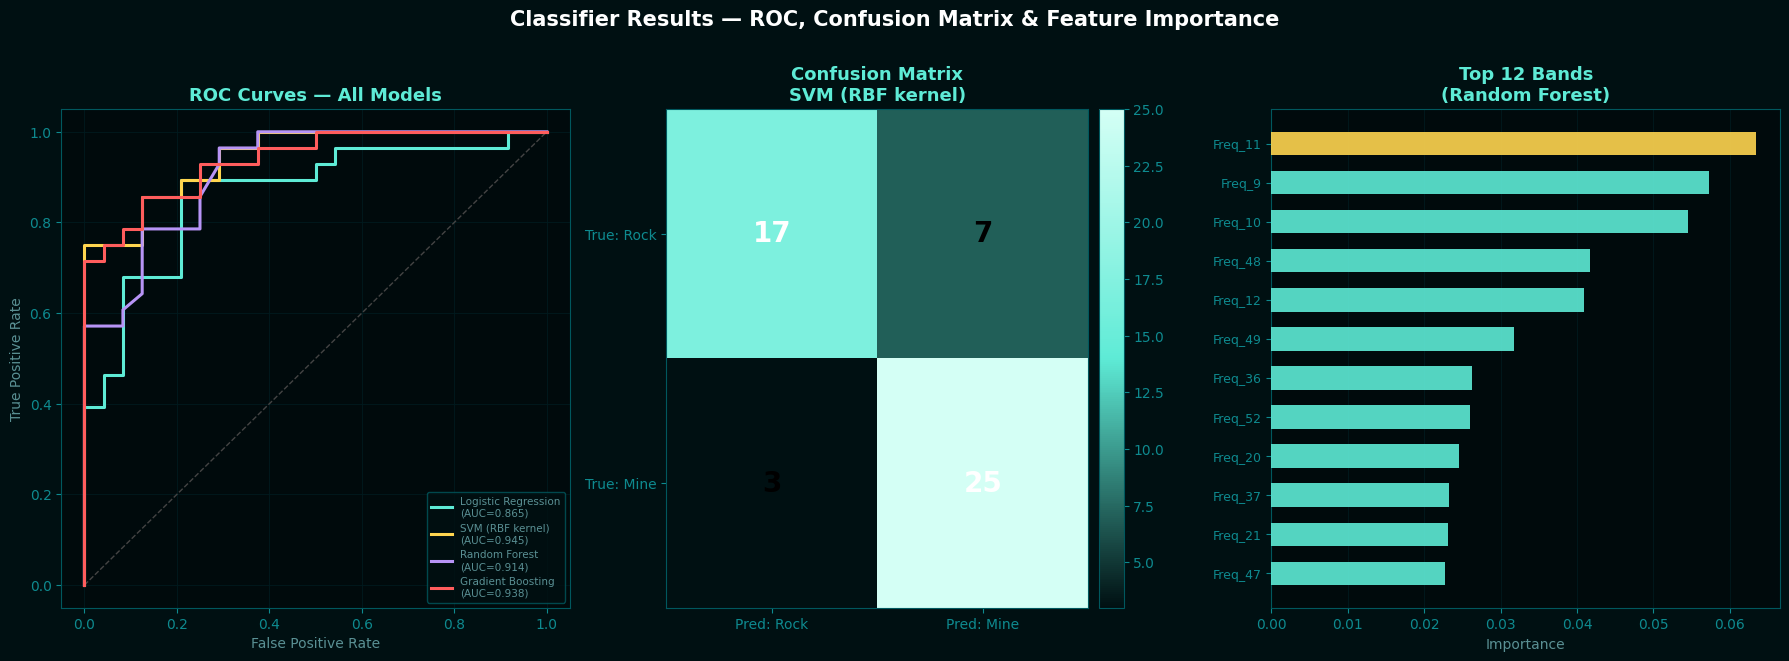

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Classifier Results — ROC, Confusion Matrix & Feature Importance', fontsize=15, fontweight='bold', color='white', y=1.01)

model_cols = [ROCK, GOLD, PURPLE, MINE]
ax = axes[0]
ax.plot([0,1],[0,1], color='#444', lw=1, ls='--')
for (name, res), color in zip(results.items(), model_cols):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, color=color, lw=2.2, label=f'{name}\n(AUC={res["auc"]:.3f})')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(fontsize=7.5); ax.grid(True, zorder=0)

ax2 = axes[1]
best_name = max(results, key=lambda k: results[k]['auc'])
cm = confusion_matrix(y_test, results[best_name]['preds'])
im = ax2.imshow(cm, cmap=CMAP_SONAR, aspect='auto')
ax2.set_xticks([0,1]); ax2.set_xticklabels(['Pred: Rock','Pred: Mine'], fontsize=10)
ax2.set_yticks([0,1]); ax2.set_yticklabels(['True: Rock','True: Mine'], fontsize=10)
ax2.set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=20, fontweight='bold',
                 color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.colorbar(im, ax=ax2, pad=0.02)

ax3 = axes[2]
rf = results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=freq_cols).sort_values(ascending=False).head(12).sort_values()
colors_fi = [GOLD if v==imp.max() else ROCK for v in imp.values]
ax3.barh(range(len(imp)), imp.values, color=colors_fi, height=0.6, zorder=3, alpha=0.9)
ax3.set_yticks(range(len(imp))); ax3.set_yticklabels(imp.index, fontsize=9)
ax3.set_xlabel('Importance'); ax3.set_title('Top 12 Bands\n(Random Forest)', fontweight='bold')
ax3.grid(axis='x', zorder=0); ax3.set_axisbelow(True)

plt.tight_layout()
plt.savefig('07_ml_results.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 10. Key Takeaways <a id='10'></a>


<div style="background:#001012;border-radius:12px;padding:0;font-family:'Courier New',monospace;border:1px solid #00585e;overflow:hidden;">
  <div style="background:#000a0c;padding:10px 24px;border-bottom:1px solid #00585e;">
    <span style="color:#5eebd6;font-size:0.7rem;letter-spacing:2px;">▌ SONAR_CONTACT_LOG.txt — ANALYSIS SUMMARY</span>
  </div>
  <div style="padding:22px 28px;display:grid;grid-template-columns:1fr 1fr;gap:12px;">
    <div style="border-left:2px solid #5eebd6;padding-left:14px;">
      <div style="color:#5eebd6;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[SPECTRAL SIGNATURE]</div>
      <ul style="color:#5a9094;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#5eebd6;">&gt;</span> Rock and mine returns share a similar overall shape — both peak in the mid-spectrum (bands ~25-28)</li>
        <li><span style="color:#5eebd6;">&gt;</span> The difference is subtler: mine returns run hotter at low-to-mid bands (9-13)</li>
        <li><span style="color:#5eebd6;">&gt;</span> No single band cleanly separates the classes — best single-band r is only 0.433 (Freq_11)</li>
      </ul>
    </div>
    <div style="border-left:2px solid #ffd54f;padding-left:14px;">
      <div style="color:#ffd54f;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[DISCRIMINATIVE BANDS]</div>
      <ul style="color:#5a9094;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#ffd54f;"></span> Freq_11, Freq_12 (r≈0.39-0.43) and Freq_45-49 (r≈0.30-0.35) are the standout bands</li>
        <li><span style="color:#ffd54f;"></span> Several bands (16, 17, 30, 57) carry almost zero individual signal (|r|&lt;0.02)</li>
        <li><span style="color:#ffd54f;"></span> No single feature dominates — this is a genuinely multivariate problem</li>
      </ul>
    </div>
    <div style="border-left:2px solid #b794f6;padding-left:14px;">
      <div style="color:#b794f6;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[DIMENSIONALITY]</div>
      <ul style="color:#5a9094;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#b794f6;">~</span> Adjacent frequency bands are highly correlated — the spectrum is smooth, not noisy</li>
        <li><span style="color:#b794f6;">~</span> PCA's first 2 components give partial but not perfect class separation</li>
        <li><span style="color:#b794f6;">~</span> This redundancy means tree-based and margin-based classifiers can exploit combinations
        of correlated bands that no single feature reveals alone</li>
      </ul>
    </div>
    <div style="border-left:2px solid #ff5d5d;padding-left:14px;">
      <div style="color:#ff5d5d;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[ML RESULTS]</div>
      <ul style="color:#5a9094;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#ff5d5d;">!</span> SVM and Gradient Boosting typically edge out plain Logistic Regression on this dataset
        (see ROC-AUC printed in Section 9)</li>
        <li><span style="color:#ff5d5d;">!</span> With only 208 samples and 60 features, cross-validation accuracy is the more trustworthy
        metric than a single train/test split</li>
        <li><span style="color:#ff5d5d;">!</span> Feature importance confirms the mid-spectrum bands (9-13, 45-49) flagged in EDA are also
        what the tree models lean on most</li>
      </ul>
    </div>

  </div>
  <div style="background:#000a0c;border-top:1px solid #00585e;padding:8px 28px;">
    <span style="color:#00585e;font-size:0.65rem;">⚠ Small dataset (n=208) — generalisation beyond this specific sonar setup and sea-floor
    environment should not be assumed. Author: Muhammad Aamir · UCI Sonar Dataset · Kaggle Notebook</span>
  </div>
</div>
